In [ ]:
# CREATED BY : REEM FAYYAZ

In [ ]:
# ============================================
# RAG-BASED HR ASSISTANT
# INSTALL REQUIRED LIBRARIES
# ============================================

# Install all libraries required to build our
# Retrieval-Augmented Generation (RAG) system.
#
# sentence-transformers:
# Converts HR documents and user questions into
# numerical embedding vectors.
#
# faiss-cpu:
# Performs fast similarity search over document
# embeddings.
#
# pypdf:
# Extracts text from PDF HR policy documents.
#
# transformers:
# Provides pre-trained NLP models that can be
# used for answer generation.
#
# accelerate:
# Helps efficiently run Transformer models.

!pip install -q sentence-transformers faiss-cpu pypdf transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 19.4 MB/s eta 0:00:00


In [ ]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

# os is used for file and directory operations.
import os

# re is used for basic text cleaning.
import re

# NumPy is used for numerical operations.
import numpy as np

# Pandas is useful for organizing retrieved
# document information.
import pandas as pd

# PyPDF extracts text from PDF documents.
from pypdf import PdfReader

# SentenceTransformer converts text into
# semantic embedding vectors.
from sentence_transformers import SentenceTransformer

# FAISS performs efficient vector similarity
# searching.
import faiss

# Display confirmation message.
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================
# CREATE DEMO HR KNOWLEDGE BASE
# ============================================

# Create a folder where our HR documents
# will be stored.

os.makedirs("/content/hr_documents", exist_ok=True)


# ============================================
# LEAVE POLICY
# ============================================

leave_policy = """
HR LEAVE POLICY

Employees are entitled to annual paid leave according
to their employment terms.

Employees should submit leave requests through the
official HR portal before taking planned leave.

For emergency or sick leave, employees should inform
their reporting manager and HR as soon as possible.

Leave approval depends on business requirements,
employee eligibility, and manager approval.

Employees should not assume that a leave request has
been approved until confirmation is received.
"""


# ============================================
# WORK FROM HOME POLICY
# ============================================

wfh_policy = """
WORK FROM HOME POLICY

Work-from-home availability depends on the employee's
role, department, and company policy.

Employees must submit a WFH request through the
approved HR process.

Manager approval may be required before working
remotely.

Employees working remotely are expected to remain
available during approved working hours and follow
company security policies.
"""


# ============================================
# ATTENDANCE POLICY
# ============================================

attendance_policy = """
ATTENDANCE POLICY

Employees are expected to follow the company's
working hours and attendance requirements.

Employees must record attendance correctly on every
working day.

If an employee forgets to mark attendance or notices
an attendance discrepancy, they should contact HR or
their reporting manager.

Repeated attendance issues may be reviewed according
to company policy.
"""


# ============================================
# PAYROLL POLICY
# ============================================

payroll_policy = """
PAYROLL POLICY

Salary is processed according to the company's
payroll calendar.

Employees can normally access their payslips through
the employee portal.

Questions regarding salary deductions, taxes, payslips,
or salary discrepancies should be directed to the
Payroll or HR team.

Employees should provide relevant employee information
when reporting a payroll issue.
"""


# ============================================
# RESIGNATION POLICY
# ============================================

resignation_policy = """
RESIGNATION AND EXIT POLICY

Employees who wish to resign should submit a formal
resignation through the approved company process.

Employees should also inform their reporting manager.

The applicable notice period depends on the employee's
employment terms and company policy.

Employees may be required to complete exit formalities,
return company property, and complete required
documentation before separation.
"""


# ============================================
# SAVE DEMO DOCUMENTS
# ============================================

documents = {
    "leave_policy.txt": leave_policy,
    "wfh_policy.txt": wfh_policy,
    "attendance_policy.txt": attendance_policy,
    "payroll_policy.txt": payroll_policy,
    "resignation_policy.txt": resignation_policy
}


for filename, content in documents.items():

    file_path = os.path.join(
        "/content/hr_documents",
        filename
    )

    with open(file_path, "w", encoding="utf-8") as file:
        file.write(content)


print("HR documents created successfully!")
print("Total documents:", len(documents))

HR documents created successfully!
Total documents: 5


In [ ]:
# ============================================
# LOAD HR DOCUMENTS
# ============================================

# This list will store the complete text
# extracted from all HR documents.

documents_data = []


# Get all files from the HR documents folder.

for filename in os.listdir("/content/hr_documents"):

    # Create the complete file path.
    file_path = os.path.join(
        "/content/hr_documents",
        filename
    )

    # Open the text file.
    with open(file_path, "r", encoding="utf-8") as file:

        # Read the complete document.
        text = file.read()

    # Store document information.
    documents_data.append({
        "filename": filename,
        "text": text
    })


# Convert the document information into
# a Pandas DataFrame.

documents_df = pd.DataFrame(documents_data)


# Display basic document information.

print("Documents Loaded:", len(documents_df))
display(documents_df)

Documents Loaded: 5


,filename,text
0,wfh_policy.txt,\nWORK FROM HOME POLICY\n\nWork-from-home avai...
1,leave_policy.txt,\nHR LEAVE POLICY\n\nEmployees are entitled to...
2,payroll_policy.txt,\nPAYROLL POLICY\n\nSalary is processed accord...
3,resignation_policy.txt,\nRESIGNATION AND EXIT POLICY\n\nEmployees who...
4,attendance_policy.txt,\nATTENDANCE POLICY\n\nEmployees are expected ...


In [ ]:
# ============================================
# CLEAN HR DOCUMENT TEXT
# ============================================

def clean_text(text):

    # Convert multiple spaces into a single space.
    text = re.sub(r"\s+", " ", text)

    # Remove unnecessary leading and trailing spaces.
    text = text.strip()

    return text


# Apply text cleaning to every document.

documents_df["clean_text"] = documents_df["text"].apply(
    clean_text
)


# Display cleaned documents.

display(
    documents_df[["filename", "clean_text"]]
)

,filename,clean_text
0,wfh_policy.txt,WORK FROM HOME POLICY Work-from-home availabil...
1,leave_policy.txt,HR LEAVE POLICY Employees are entitled to annu...
2,payroll_policy.txt,PAYROLL POLICY Salary is processed according t...
3,resignation_policy.txt,RESIGNATION AND EXIT POLICY Employees who wish...
4,attendance_policy.txt,ATTENDANCE POLICY Employees are expected to fo...


In [ ]:
# ============================================
# DOCUMENT CHUNKING
# ============================================

def create_chunks(text, chunk_size=80, overlap=20):

    # Split the document into individual words.
    words = text.split()

    chunks = []

    # Start position of the current chunk.
    start = 0

    # Continue until the complete document
    # has been processed.

    while start < len(words):

        # Calculate the ending position.
        end = start + chunk_size

        # Create one chunk.
        chunk = " ".join(words[start:end])

        # Store the chunk.
        chunks.append(chunk)

        # Move forward while maintaining overlap.
        #
        # Example:
        # Chunk 1 → words 1-80
        # Chunk 2 → words 61-140
        #
        # The overlapping section helps preserve
        # contextual information between chunks.

        start += chunk_size - overlap

    return chunks


# ============================================
# CREATE ALL DOCUMENT CHUNKS
# ============================================

chunks = []


for _, row in documents_df.iterrows():

    # Create chunks for the current document.
    document_chunks = create_chunks(
        row["clean_text"]
    )

    # Store every chunk with its source document.
    for chunk in document_chunks:

        chunks.append({
            "filename": row["filename"],
            "text": chunk
        })


# Convert chunks into a DataFrame.

chunks_df = pd.DataFrame(chunks)


# Display chunk information.

print("Total Chunks:", len(chunks_df))

display(chunks_df.head(10))

Total Chunks: 6


,filename,text
0,wfh_policy.txt,WORK FROM HOME POLICY Work-from-home availabil...
1,leave_policy.txt,HR LEAVE POLICY Employees are entitled to annu...
2,leave_policy.txt,assume that a leave request has been approved ...
3,payroll_policy.txt,PAYROLL POLICY Salary is processed according t...
4,resignation_policy.txt,RESIGNATION AND EXIT POLICY Employees who wish...
5,attendance_policy.txt,ATTENDANCE POLICY Employees are expected to fo...


In [ ]:
# ============================================
# LOAD EMBEDDING MODEL
# ============================================

# SentenceTransformer creates semantic embeddings.
#
# Unlike simple keyword matching, embeddings help
# the system understand semantic similarity.
#
# For example:
#
# "How many vacation days do I get?"
#
# and
#
# "What is the annual leave policy?"
#
# contain different words but have similar meaning.

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)


print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


In [ ]:
# ============================================
# GENERATE DOCUMENT EMBEDDINGS
# ============================================

# Convert every document chunk into an embedding vector.

document_embeddings = embedding_model.encode(
    chunks_df["text"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True
)


# Display embedding shape.

print("Embedding Shape:", document_embeddings.shape)

Embedding Shape: (6, 384)


In [ ]:
# ============================================
# CREATE FAISS VECTOR INDEX
# ============================================

# Get the number of dimensions in our embedding vectors.

embedding_dimension = document_embeddings.shape[1]


# Create a FAISS index using inner-product similarity.
#
# Because embeddings are normalized, inner product
# behaves similarly to cosine similarity.

index = faiss.IndexFlatIP(
    embedding_dimension
)


# Add all HR document embeddings to the index.

index.add(document_embeddings)


# Display index information.

print("FAISS index created successfully!")
print("Total vectors stored:", index.ntotal)

FAISS index created successfully!
Total vectors stored: 6


In [ ]:
# ============================================
# HR DOCUMENT RETRIEVER
# ============================================

def retrieve_documents(query, top_k=3):

    # Convert the user's question into an embedding.

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )


    # Search the FAISS index for the most similar
    # document chunks.

    scores, indices = index.search(
        query_embedding,
        top_k
    )


    retrieved_documents = []


    # Collect the retrieved chunks.

    for score, idx in zip(scores[0], indices[0]):

        # Ignore invalid indexes.
        if idx == -1:
            continue

        retrieved_documents.append({
            "score": float(score),
            "filename": chunks_df.iloc[idx]["filename"],
            "text": chunks_df.iloc[idx]["text"]
        })


    return retrieved_documents

In [ ]:
# ============================================
# TEST DOCUMENT RETRIEVAL
# ============================================

query = "How can I apply for annual leave?"


results = retrieve_documents(
    query,
    top_k=3
)


print("User Query:")
print(query)

print("\n====================================")
print("RETRIEVED HR INFORMATION")
print("====================================")


for result in results:

    print("\nSource:", result["filename"])
    print("Similarity Score:", round(result["score"], 4))
    print("Content:", result["text"])

User Query:
How can I apply for annual leave?

RETRIEVED HR INFORMATION

Source: leave_policy.txt
Similarity Score: 0.4593
Content: HR LEAVE POLICY Employees are entitled to annual paid leave according to their employment terms. Employees should submit leave requests through the official HR portal before taking planned leave. For emergency or sick leave, employees should inform their reporting manager and HR as soon as possible. Leave approval depends on business requirements, employee eligibility, and manager approval. Employees should not assume that a leave request has been approved until confirmation is received.

Source: leave_policy.txt
Similarity Score: 0.4298
Content: assume that a leave request has been approved until confirmation is received.

Source: resignation_policy.txt
Similarity Score: 0.4123
Content: RESIGNATION AND EXIT POLICY Employees who wish to resign should submit a formal resignation through the approved company process. Employees should also inform their report

In [ ]:
# ============================================
# LOAD TEXT GENERATION MODEL
# ============================================

from transformers import pipeline


# Create a text-generation pipeline.
#
# This model will generate the final answer
# using the context retrieved from our HR
# knowledge base.

generator = pipeline(
    "text-generation",
    model="google/flan-t5-small"
)


print("Text generation model loaded successfully!")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  308MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


...

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'AXK1ForCausalLM', 'AXK2ForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CohereCompassForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DeepseekV32ForCausalLM', 'DeepseekV4ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM',

Text generation model loaded successfully!


In [ ]:
# ============================================
# RAG-BASED HR ANSWER GENERATION
# ============================================

def generate_hr_answer(user_query, top_k=3):

    # ========================================
    # STEP 1: RETRIEVE RELEVANT DOCUMENTS
    # ========================================

    retrieved_documents = retrieve_documents(
        user_query,
        top_k=top_k
    )


    # ========================================
    # STEP 2: COMBINE RETRIEVED CONTEXT
    # ========================================

    context = "\n\n".join(
        [
            f"Source: {doc['filename']}\n{doc['text']}"
            for doc in retrieved_documents
        ]
    )


    # ========================================
    # STEP 3: CREATE RAG PROMPT
    # ========================================

    prompt = f"""
You are a professional HR Assistant.

Answer the employee's question using ONLY
the HR policy information provided below.

If the answer is not available in the provided
context, clearly say that the information is not
available and advise the employee to contact HR.

Do not invent company policies.

HR POLICY CONTEXT:
{context}

EMPLOYEE QUESTION:
{user_query}

ANSWER:
"""


    # ========================================
    # STEP 4: GENERATE FINAL ANSWER
    # ========================================

    result = generator(
        prompt,
        max_new_tokens=120,
        do_sample=False
    )


    # Extract generated text.

    answer = result[0]["generated_text"]


    return answer

In [ ]:
# ============================================
# TEST COMPLETE RAG HR ASSISTANT
# ============================================

user_query = "Can I work from home?"

answer = generate_hr_answer(
    user_query
)


print("====================================")
print("RAG HR ASSISTANT")
print("====================================")

print("\nUser:")
print(user_query)

print("\nHR Assistant:")
print(answer)

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


RAG HR ASSISTANT

User:
Can I work from home?

HR Assistant:

You are a professional HR Assistant.

Answer the employee's question using ONLY
the HR policy information provided below.

If the answer is not available in the provided
context, clearly say that the information is not
available and advise the employee to contact HR.

Do not invent company policies.

HR POLICY CONTEXT:
Source: wfh_policy.txt
WORK FROM HOME POLICY Work-from-home availability depends on the employee's role, department, and company policy. Employees must submit a WFH request through the approved HR process. Manager approval may be required before working remotely. Employees working remotely are expected to remain available during approved working hours and follow company security policies.

Source: leave_policy.txt
assume that a leave request has been approved until confirmation is received.

Source: leave_policy.txt
HR LEAVE POLICY Employees are entitled to annual paid leave according to their employment terms

#Suppose user asks:

"Can I take leave tomorrow?"

Step 1 — Query

User Question

     ↓

"Can I take leave tomorrow?"

Step 2 — Embedding

Question

   ↓

Embedding Model

   ↓
   
Numerical Vector

Step 3 — Retrieval

Vector

   ↓

FAISS

   ↓

Top 3 Relevant Chunks

Example:

leave_policy.txt

attendance_policy.txt

resignation_policy.txt

Step 4 — Context

Relevant HR Policy

        +

User Question

        ↓

       Prompt

Step 5 — Generation

Prompt

   ↓

LLM

   ↓

Professional HR Answer

In [ ]:
# ============================================
# INTERACTIVE RAG HR ASSISTANT
# ============================================

print("==============================================")
print("       RAG-BASED HR ASSISTANT")
print("==============================================")

print("Ask questions about HR policies.")
print("Type 'exit' to stop the chatbot.")


while True:

    # Get question from the user.

    user_query = input("\nYou: ")


    # Check exit commands.

    if user_query.lower().strip() in [
        "exit",
        "quit",
        "bye"
    ]:

        print("\nHR Assistant: Goodbye! 👋")
        break


    # Handle empty input.

    if not user_query.strip():

        print("\nHR Assistant: Please enter a question.")
        continue


    # Generate RAG-based answer.

    answer = generate_hr_answer(
        user_query
    )


    # Display the answer.

    print("\nHR Assistant:", answer)

       RAG-BASED HR ASSISTANT
Ask questions about HR policies.
Type 'exit' to stop the chatbot.
System Error: np.int64(0)

HR Assistant: Sorry, I could not process your question at the moment. Please try again or contact HR.


In [ ]:
# ============================================
# SAVE RAG HR ASSISTANT
# ============================================

import joblib


# Save document metadata and chatbot configuration.

rag_package = {

    # Store document chunks.

    "chunks": chunks_df.to_dict(
        orient="records"
    ),

    # Store embedding model name so it can
    # be loaded again during deployment.

    "embedding_model_name": "all-MiniLM-L6-v2",

    # Number of retrieved documents.

    "top_k": 3,

    # Project name.

    "name": "RAG-Based HR Assistant"
}


# Define PKL path.

rag_pkl_path = "/content/rag_hr_assistant.pkl"


# Save configuration and metadata.

joblib.dump(
    rag_package,
    rag_pkl_path
)


print("====================================")
print("RAG PACKAGE SAVED SUCCESSFULLY")
print("====================================")
print("File:", rag_pkl_path)

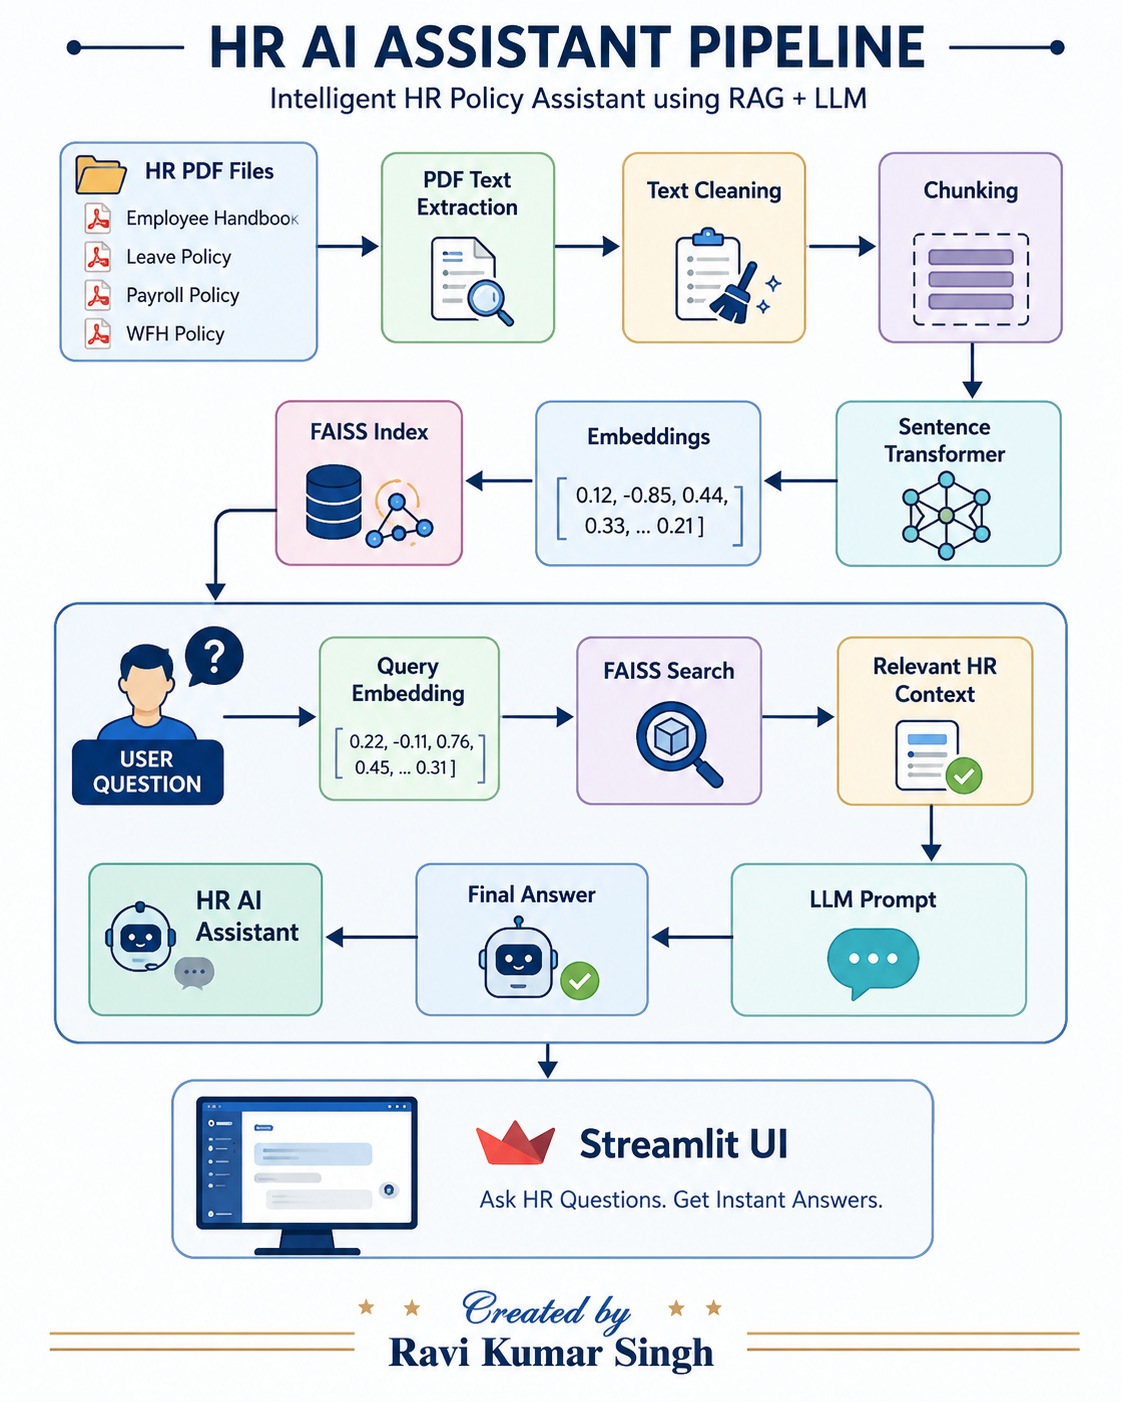